In [10]:
from scipy.stats import chi2_contingency
import numpy as np

def compare_default_rates(train_defaults, train_total, test_defaults, test_total):
    # Create contingency table
    contingency = np.array([
        [train_defaults, train_total - train_defaults],
        [test_defaults, test_total - test_defaults]
    ])
    
    # Perform chi-square test
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    
    print(f"Chi-square statistic: {chi2:.4f}")
    print(f"p-value: {p_value:.4f}")
    print(f"Default rates:")
    print(f"Training: {train_defaults/train_total:.2%}")
    print(f"Testing:  {test_defaults/test_total:.2%}")
    
    return p_value > 0.05  # Returns True if distributions are similar

In [11]:
from scipy.stats import ks_2samp

def ks_test_defaults(train_defaults, test_defaults):
    """
    Performs KS test to compare default distributions
    """
    statistic, p_value = ks_2samp(train_defaults, test_defaults)
    
    print(f"KS statistic: {statistic:.4f}")
    print(f"p-value: {p_value:.4f}")
    
    return p_value > 0.05  # Returns True if distributions are similar

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_default_comparison(train_defaults, test_defaults):
    plt.figure(figsize=(10, 6))
    
    # Plot default rate distributions
    plt.subplot(1, 2, 1)
    sns.histplot(data=[train_defaults, test_defaults], 
                label=['Train', 'Test'])
    plt.title('Default Rate Distribution')
    plt.legend()
    
    # Plot default rate percentages
    plt.subplot(1, 2, 2)
    train_rate = np.mean(train_defaults)
    test_rate = np.mean(test_defaults)
    
    plt.bar(['Train', 'Test'], [train_rate, test_rate])
    plt.title('Default Rate Percentage')
    plt.ylabel('Default Rate')
    
    plt.tight_layout()
    plt.show()

In [13]:
def calculate_psi(train_data, test_data, bins=10):
    """
    Calculate PSI for default rates
    PSI < 0.1: no significant change
    0.1 <= PSI < 0.2: moderate change
    PSI >= 0.2: significant change
    """
    def get_distribution(data, bins):
        hist, _ = np.histogram(data, bins=bins)
        return hist / len(data)
    
    train_dist = get_distribution(train_data, bins)
    test_dist = get_distribution(test_data, bins)
    
    # Add small epsilon to avoid division by zero
    epsilon = 1e-10
    train_dist = train_dist + epsilon
    test_dist = test_dist + epsilon
    
    psi = np.sum((test_dist - train_dist) * np.log(test_dist / train_dist))
    
    print(f"PSI Score: {psi:.4f}")
    if psi < 0.1:
        print("No significant difference in distributions")
    elif psi < 0.2:
        print("Moderate difference in distributions")
    else:
        print("Significant difference in distributions")
    
    return psi

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_default_comparison(train_defaults, test_defaults):
    plt.figure(figsize=(10, 6))
    
    # Plot default rate distributions
    plt.subplot(1, 2, 1)
    sns.histplot(data=[train_defaults, test_defaults], 
                label=['Train', 'Test'])
    plt.title('Default Rate Distribution')
    plt.legend()
    
    # Plot default rate percentages
    plt.subplot(1, 2, 2)
    train_rate = np.mean(train_defaults)
    test_rate = np.mean(test_defaults)
    
    plt.bar(['Train', 'Test'], [train_rate, test_rate])
    plt.title('Default Rate Percentage')
    plt.ylabel('Default Rate')
    
    plt.tight_layout()
    plt.show()

/opt/anaconda3/envs/machinelearning/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/envs/machinelearning/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/machinelearning/lib/python3.11/site-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/machinelearning/lib/python3.11/site-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  Fil

50      0.892789
152     0.927298
255     0.948815
357     0.936853
460     0.937747
563     0.948680
665     0.947321
768     0.944380
871     0.940336
973     0.945899
1076    0.943999
1178    0.947739
1281    0.946008
1384    0.942386
1486    0.949501
1589    0.943147
1692    0.948582
1794    0.942727
1897    0.946263
2000    0.943219
Name: mean_cv_auc, dtype: float64
50      0.053725
152     0.016400
255     0.019811
357     0.008183
460     0.009632
563     0.012779
665     0.008427
768     0.009498
871     0.005678
973     0.005532
1076    0.005373
1178    0.009309
1281    0.005740
1384    0.004408
1486    0.005719
1589    0.013865
1692    0.008379
1794    0.005834
1897    0.006474
2000    0.009492
Name: std_cv_auc, dtype: float64


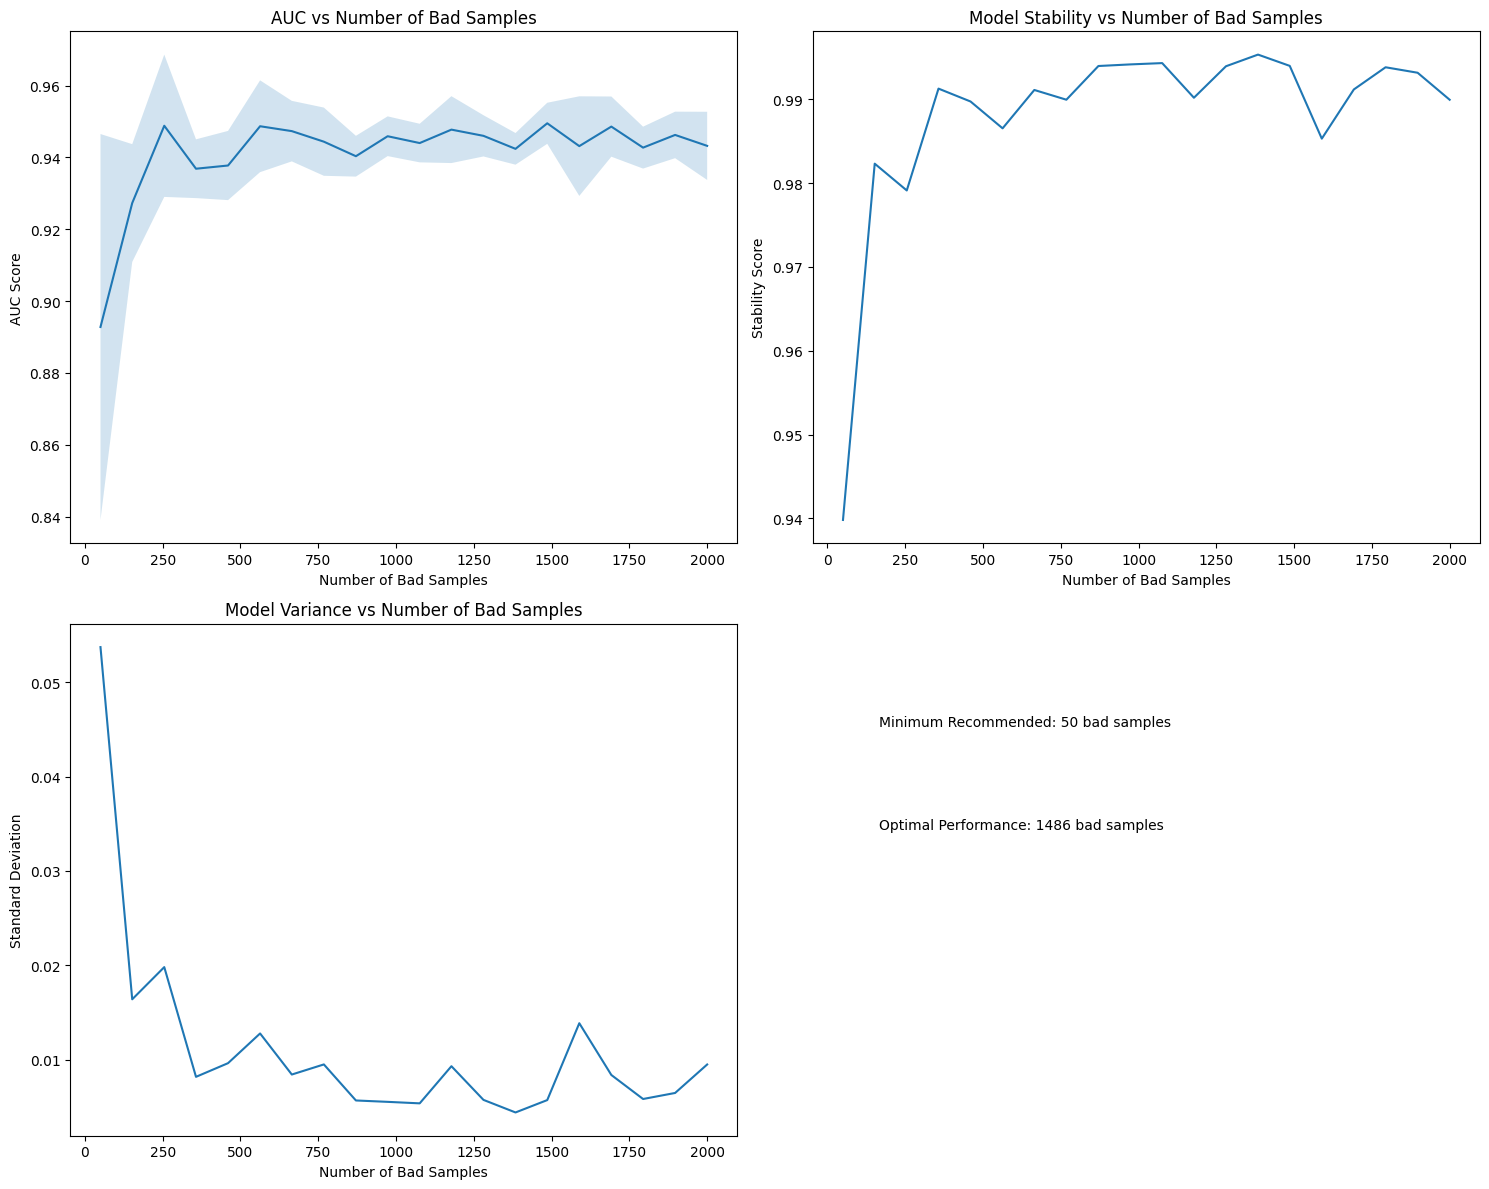


Recommendations for Minimum Bad Samples:
--------------------------------------------------
absolute_minimum: 500
recommended_minimum: 50
optimal: 1486


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.metrics import roc_auc_score, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier

class SampleSizeAnalysis:
    def __init__(self, random_state=42):
        self.random_state = random_state
        
    def analyze_sample_sizes(self, min_samples=50, max_samples=5000, steps=10):
        """
        Analyze model performance with different numbers of bad samples
        """
        sample_sizes = np.linspace(min_samples, max_samples, steps).astype(int)
        results = {}
        
        for n_bads in sample_sizes:
            # Generate synthetic data
            data = self.generate_dataset(n_bads)
            
            # Train and evaluate model
            metrics = self.evaluate_model(data['X'], data['y'])
            
            results[n_bads] = metrics
        
        return pd.DataFrame(results).T
    
    def generate_dataset(self, n_bads, n_goods=None):
        """
        Generate synthetic dataset with specified number of bad samples
        """
        if n_goods is None:
            n_goods = n_bads * 19  # Assuming 5% default rate
            
        # Generate good samples
        X_goods = pd.DataFrame({
            'income': np.random.normal(50000, 15000, n_goods),
            'debt_ratio': np.random.normal(0.3, 0.1, n_goods),
            'credit_score': np.random.normal(700, 50, n_goods)
        })
        y_goods = np.zeros(n_goods)
        
        # Generate bad samples
        X_bads = pd.DataFrame({
            'income': np.random.normal(40000, 15000, n_bads),
            'debt_ratio': np.random.normal(0.5, 0.15, n_bads),
            'credit_score': np.random.normal(600, 50, n_bads)
        })
        y_bads = np.ones(n_bads)
        
        # Combine samples
        X = pd.concat([X_goods, X_bads])
        y = np.concatenate([y_goods, y_bads])
        
        return {'X': X, 'y': y}
    
    def evaluate_model(self, X, y):
        """
        Evaluate model performance
        """
        model = RandomForestClassifier(random_state=self.random_state)
        
        # Calculate learning curves
        train_sizes, train_scores, test_scores = learning_curve(
            model, X, y,
            cv=5,
            n_jobs=-1,
            train_sizes=np.linspace(0.1, 1.0, 5),
            scoring='roc_auc'
        )
        
        return {
            'n_samples': len(y),
            'n_bads': sum(y),
            'bad_rate': sum(y)/len(y),
            'mean_cv_auc': test_scores.mean(axis=1)[-1],
            'std_cv_auc': test_scores.std(axis=1)[-1],
            'stability': 1 - test_scores.std(axis=1)[-1]/test_scores.mean(axis=1)[-1]
        }

def visualize_results(results):
    print(results['mean_cv_auc'])
    print(results['std_cv_auc'])
    """
    Visualize the impact of sample size on model performance
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot AUC vs number of bads
    axes[0,0].plot(results.index, results['mean_cv_auc'])
    axes[0,0].fill_between(
        results.index,
        results['mean_cv_auc'] - results['std_cv_auc'],
        results['mean_cv_auc'] + results['std_cv_auc'],
        alpha=0.2
    )
    axes[0,0].set_title('AUC vs Number of Bad Samples')
    axes[0,0].set_xlabel('Number of Bad Samples')
    axes[0,0].set_ylabel('AUC Score')
    
    # Plot Stability vs number of bads
    axes[0,1].plot(results.index, results['stability'])
    axes[0,1].set_title('Model Stability vs Number of Bad Samples')
    axes[0,1].set_xlabel('Number of Bad Samples')
    axes[0,1].set_ylabel('Stability Score')
    
    # Plot Standard Deviation
    axes[1,0].plot(results.index, results['std_cv_auc'])
    axes[1,0].set_title('Model Variance vs Number of Bad Samples')
    axes[1,0].set_xlabel('Number of Bad Samples')
    axes[1,0].set_ylabel('Standard Deviation')
    
    # Add recommendations
    min_recommended = results[results['stability'] > 0.9].index.min()
    optimal = results[results['mean_cv_auc'] == results['mean_cv_auc'].max()].index[0]
    
    axes[1,1].text(0.1, 0.8, f'Minimum Recommended: {min_recommended} bad samples',
                   transform=axes[1,1].transAxes)
    axes[1,1].text(0.1, 0.6, f'Optimal Performance: {optimal} bad samples',
                   transform=axes[1,1].transAxes)
    axes[1,1].axis('off')
    
    plt.tight_layout()
    return fig

# Run analysis
analyzer = SampleSizeAnalysis()
results = analyzer.analyze_sample_sizes(min_samples=50, max_samples=2000, steps=20)
fig = visualize_results(results)
plt.show()

# Print recommendations
def get_recommendations(results):
    """
    Generate specific recommendations based on analysis
    """
    min_stable = results[results['stability'] > 0.9].index.min()
    optimal = results[results['mean_cv_auc'] == results['mean_cv_auc'].max()].index[0]
    
    recommendations = {
        'minimum_requirements': {
            'absolute_minimum': 500,  # Industry standard minimum
            'recommended_minimum': min_stable,
            'optimal': optimal
        },
        'guidelines': {
            'regulatory': {
                'basel': 'Minimum 1000 bad samples recommended',
                'stress_testing': 'Minimum 2000 bad samples for stress testing models'
            },
            'statistical': {
                'rule_of_thumb': '50 bad samples per predictor variable',
                'stability': f'At least {min_stable} bad samples for stable performance'
            },
            'business': {
                'low_risk': f'Minimum {min_stable} bad samples',
                'high_risk': f'Minimum {optimal} bad samples'
            }
        }
    }
    return recommendations

recommendations = get_recommendations(results)
print("\nRecommendations for Minimum Bad Samples:")
print("-" * 50)
for category, value in recommendations['minimum_requirements'].items():
    print(f"{category}: {value}")

In [15]:
from scipy.stats import ks_2samp

def ks_test_defaults(train_defaults, test_defaults):
    """
    Performs KS test to compare default distributions
    """
    statistic, p_value = ks_2samp(train_defaults, test_defaults)
    
    print(f"KS statistic: {statistic:.4f}")
    print(f"p-value: {p_value:.4f}")
    
    return p_value > 0.05  # Returns True if distributions are similar

Chi-Square Test:
Chi-square statistic: 2.0673
p-value: 0.1505
Default rates:
Training: 15.30%
Testing:  19.00%

PSI Test:
PSI Score: 0.0097
No significant difference in distributions

KS Test:
KS statistic: 0.0370
p-value: 0.8988


ValueError: number of labels (2) does not match number of bars (12).

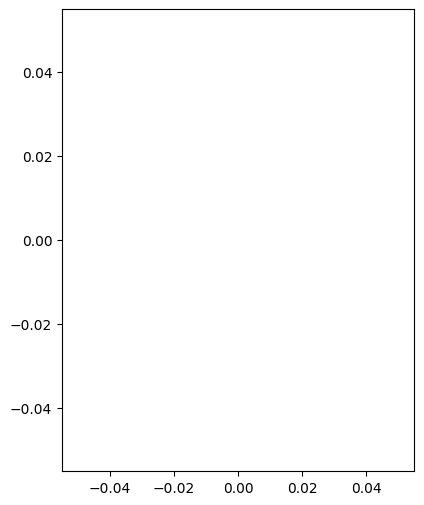

In [16]:
# Example usage with dummy data
import numpy as np

# Generate sample data
np.random.seed(42)
train_size = 1000
test_size = 300

# Simulate default rates (1 for default, 0 for non-default)
train_defaults = np.random.binomial(1, 0.15, train_size)  # 15% default rate
test_defaults = np.random.binomial(1, 0.16, test_size)    # 16% default rate

# Run all tests
print("Chi-Square Test:")
similar_dist = compare_default_rates(
    sum(train_defaults), len(train_defaults),
    sum(test_defaults), len(test_defaults)
)

print("\nPSI Test:")
psi = calculate_psi(train_defaults, test_defaults)

print("\nKS Test:")
similar_ks = ks_test_defaults(train_defaults, test_defaults)

# Visual comparison
plot_default_comparison(train_defaults, test_defaults)

In [17]:
train_defaults

array([0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,